# 03 - Analyse Exploratoire Bivariée (Bivariate EDA)
## Projet de Prédiction des Maladies Cardiovasculaires

Ce notebook est consacré à l'**analyse exploratoire bivariée** des variables du dataset cardiovasculaire.  
L'objectif est d'étudier les relations **deux à deux** entre les caractéristiques, en accordant une attention particulière à la variable cible `target` (présence ou absence de maladie cardiovasculaire).

Ce document s'articule autour des 7 thématiques méthodologiques clés :
1. **Analyser deux variables en utilisant un scatter plot** (relations continues et frontières de décision).
2. **Création de tables de contingence** (croisements catégoriels, tests du $\chi^2$ et calcul du V de Cramér).
3. **Générer les pairplots sur les variables deux à deux** (vue d'ensemble multidimensionnelle selon la cible).
4. **Analyser les variables avec les bar charts** (comparaison des effectifs et taux de MCV intra-modalités).
5. **Générer les boxplots pour paire de variables** (distributions numériques selon la cible et tests de significativité).
6. **Créer des histogrammes par paires** (décalages et chevauchements des distributions selon la cible).
7. **Analyser les variables deux à deux en faisant la corrélation** (matrices de Pearson et Spearman, diagnostic de multicolinéarité).

---

## 0. Configuration de l'environnement et chargement des données

In [1]:
# Imports des bibliothèques nécessaires
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Configuration globale de l'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

# Configuration esthétique Seaborn et Matplotlib
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [2]:
# Chargement robuste du jeu de données
possible_paths = [
    os.path.join("data", "cardiovascular.csv"),
    os.path.join("notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "notebooks", "data", "cardiovascular.csv"),
    os.path.join("..", "data", "cardiovascular.csv")
]

csv_path = next((path for path in possible_paths if os.path.exists(path)), None)
if csv_path is None:
    raise FileNotFoundError("Le fichier 'cardiovascular.csv' est introuvable.")

df = pd.read_csv(csv_path)
print(f"Dataset chargé avec succès depuis : {csv_path}")
print(f"Dimensions : {df.shape[0]} observations, {df.shape[1]} variables.")
df.head()

Dataset chargé avec succès depuis : data\cardiovascular.csv
Dimensions : 1000 observations, 14 variables.
Out[0]: 
   patientid  age  gender  chestpain  restingBP  serumcholestrol  fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  slope  noofmajorvessels  target
0     103368   53       1          2        171                0                  0                1           147              0      5.3      3                 3       1
1     119250   40       1          0         94              229                  0                1           115              0      3.7      1                 1       0
2     119372   49       1          2        133              142                  0                0           202              1      5.0      1                 0       0
3     132514   43       1          0        138              295                  1                1           153              0      3.2      2                 2       1
4     146211   31       1

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


### Préparation des variables et création du DataFrame annoté

Pour les calculs numériques et statistiques, nous conservons les valeurs originales dans `df`.  
Pour la clarté visuelle des graphiques et des tableaux, nous créons `df_plot` qui contient les libellés médicaux explicites pour toutes les variables catégorielles ainsi que pour la variable cible.

In [3]:
# Définition des groupes de variables
target_col = 'target'
numeric_cols = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']
categorical_cols = [
    'gender', 'chestpain', 'fastingbloodsugar', 'restingrelectro',
    'exerciseangia', 'slope', 'noofmajorvessels'
]

# Dictionnaire de correspondances médicales
label_maps = {
    'target': {0: 'Sain (pas de MCV)', 1: 'Atteint (présence de MCV)'},
    'gender': {0: 'Femme', 1: 'Homme'},
    'chestpain': {0: 'Asymptomatique', 1: 'Angine atypique', 2: 'Douleur non angineuse', 3: 'Angine typique'},
    'fastingbloodsugar': {0: 'Normale (≤ 120 mg/dL)', 1: 'Élevée (> 120 mg/dL)'},
    'restingrelectro': {0: 'Normal', 1: 'Anomalie ST-T', 2: 'Hypertrophie VG'},
    'exerciseangia': {0: 'Non', 1: 'Oui'},
    'slope': {0: 'Non documenté (0)', 1: 'Ascendante (Up)', 2: 'Plate (Flat)', 3: 'Descendante (Down)'},
    'noofmajorvessels': {0: '0 vaisseau', 1: '1 vaisseau', 2: '2 vaisseaux', 3: '3 vaisseaux'}
}

# DataFrame enrichi pour les visualisations
df_plot = df.copy()
for col, mapping in label_maps.items():
    df_plot[f'{col}_label'] = df_plot[col].map(mapping)

print("Variables préparées pour l'analyse bivariée.")

Variables préparées pour l'analyse bivariée.


---
## 1. Analyser deux variables en utilisant un Scatter Plot

Les nuages de points (*scatter plots*) permettent d'examiner la relation conjointe entre **deux variables numériques continues**, de repérer d'éventuels groupements (*clusters*) et d'évaluer la séparabilité des classes en colorant les points selon la variable `target`.

Nous explorons 4 paires cliniquement significatives :
1. **Pression artérielle (`restingBP`) vs Cholestérol sérique (`serumcholestrol`)**
2. **Âge (`age`) vs Fréquence cardiaque maximale (`maxheartrate`)**
3. **Fréquence cardiaque maximale (`maxheartrate`) vs Dépression ST (`oldpeak`)**
4. **Âge (`age`) vs Pression artérielle (`restingBP`)**

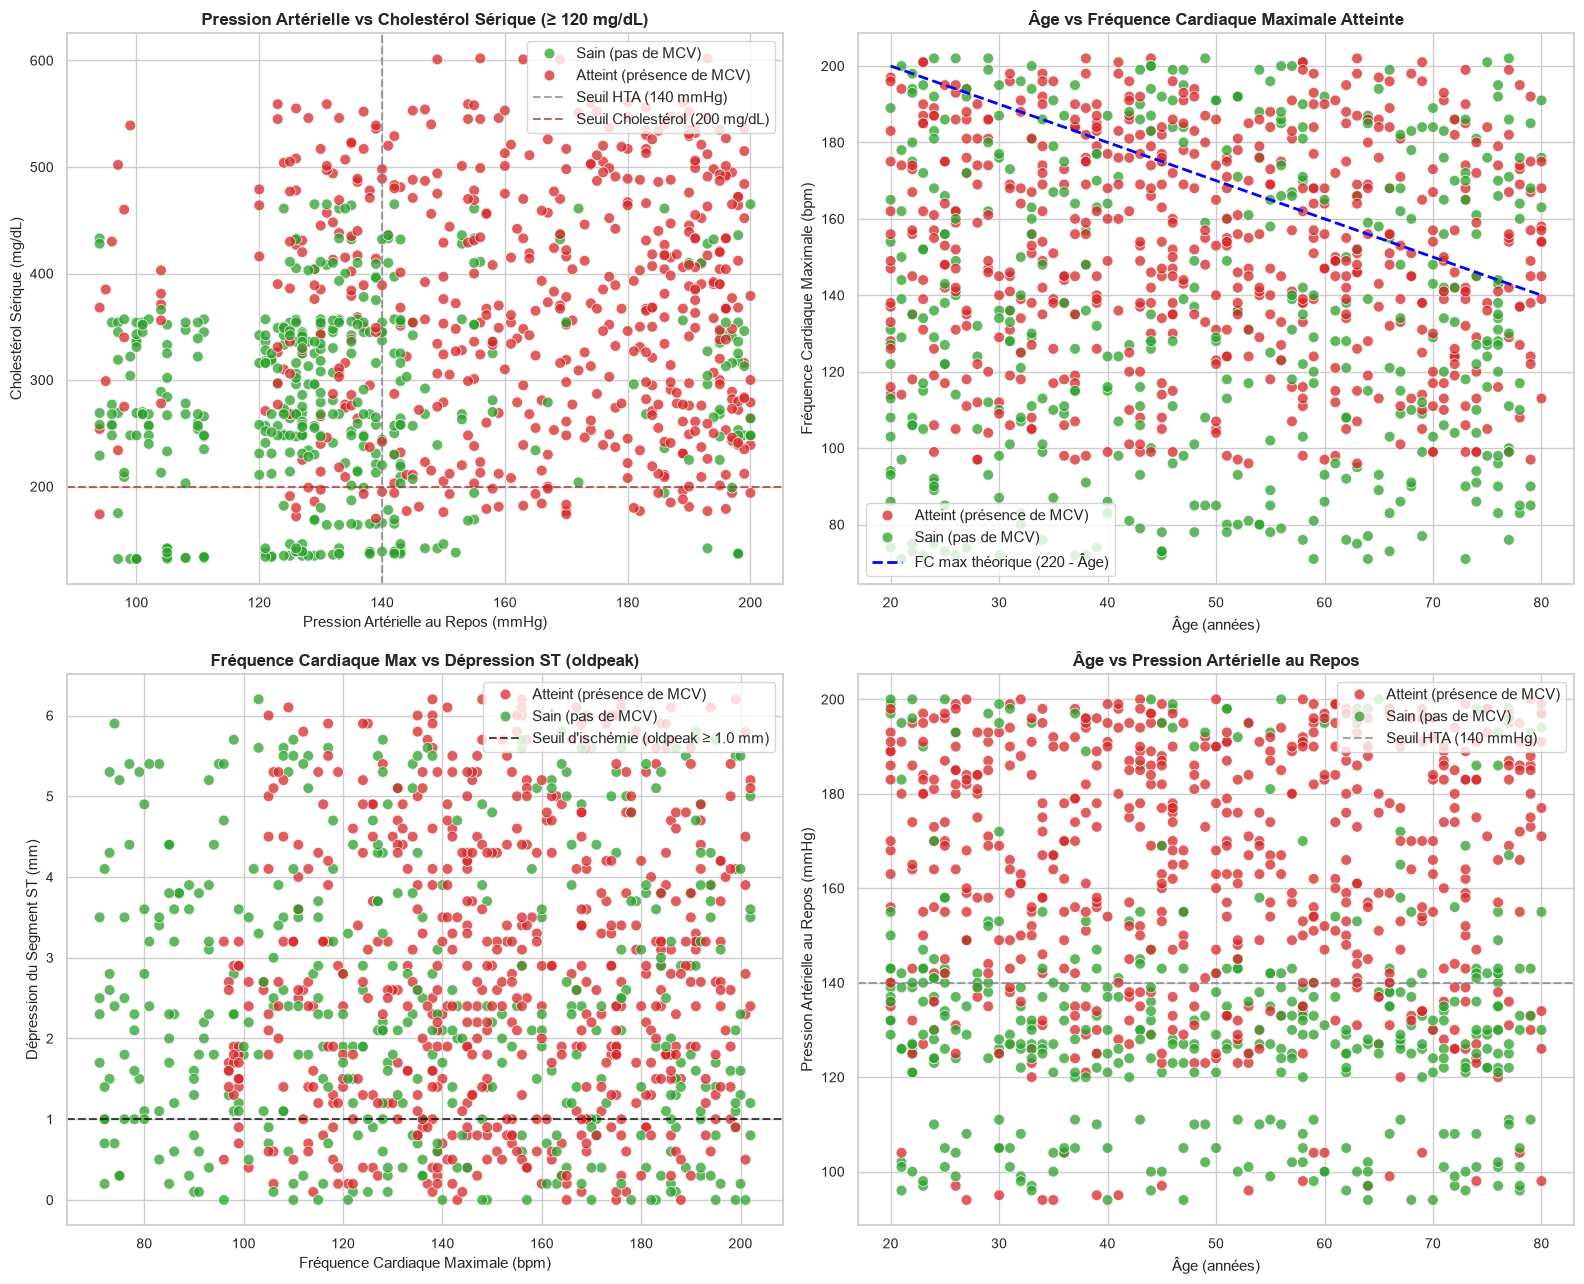

In [4]:
# Palette de couleur cohérente pour la cible
palette_target = {'Sain (pas de MCV)': '#2ca02c', 'Atteint (présence de MCV)': '#d62728'}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# 1. restingBP vs serumcholestrol (en excluant les zéros de cholestérol pour le tracé)
df_valid_chol = df_plot[df_plot['serumcholestrol'] >= 120]
sns.scatterplot(
    data=df_valid_chol, x='restingBP', y='serumcholestrol',
    hue='target_label', palette=palette_target, alpha=0.75, s=60, ax=axes[0, 0]
)
axes[0, 0].axvline(140, color='gray', linestyle='--', alpha=0.7, label='Seuil HTA (140 mmHg)')
axes[0, 0].axhline(200, color='brown', linestyle='--', alpha=0.7, label='Seuil Cholestérol (200 mg/dL)')
axes[0, 0].set_title("Pression Artérielle vs Cholestérol Sérique (≥ 120 mg/dL)", fontweight='bold')
axes[0, 0].set_xlabel("Pression Artérielle au Repos (mmHg)")
axes[0, 0].set_ylabel("Cholestérol Sérique (mg/dL)")
axes[0, 0].legend(loc='upper right', frameon=True)

# 2. age vs maxheartrate (avec droite théorique 220 - âge)
sns.scatterplot(
    data=df_plot, x='age', y='maxheartrate',
    hue='target_label', palette=palette_target, alpha=0.75, s=60, ax=axes[0, 1]
)
ages_range = np.linspace(20, 80, 100)
axes[0, 1].plot(ages_range, 220 - ages_range, color='blue', linestyle='--', linewidth=2, label='FC max théorique (220 - Âge)')
axes[0, 1].set_title("Âge vs Fréquence Cardiaque Maximale Atteinte", fontweight='bold')
axes[0, 1].set_xlabel("Âge (années)")
axes[0, 1].set_ylabel("Fréquence Cardiaque Maximale (bpm)")
axes[0, 1].legend(loc='lower left', frameon=True)

# 3. maxheartrate vs oldpeak
sns.scatterplot(
    data=df_plot, x='maxheartrate', y='oldpeak',
    hue='target_label', palette=palette_target, alpha=0.75, s=60, ax=axes[1, 0]
)
axes[1, 0].axhline(1.0, color='black', linestyle='--', alpha=0.7, label='Seuil d\'ischémie (oldpeak ≥ 1.0 mm)')
axes[1, 0].set_title("Fréquence Cardiaque Max vs Dépression ST (oldpeak)", fontweight='bold')
axes[1, 0].set_xlabel("Fréquence Cardiaque Maximale (bpm)")
axes[1, 0].set_ylabel("Dépression du Segment ST (mm)")
axes[1, 0].legend(loc='upper right', frameon=True)

# 4. age vs restingBP
sns.scatterplot(
    data=df_plot, x='age', y='restingBP',
    hue='target_label', palette=palette_target, alpha=0.75, s=60, ax=axes[1, 1]
)
axes[1, 1].axhline(140, color='gray', linestyle='--', alpha=0.7, label='Seuil HTA (140 mmHg)')
axes[1, 1].set_title("Âge vs Pression Artérielle au Repos", fontweight='bold')
axes[1, 1].set_xlabel("Âge (années)")
axes[1, 1].set_ylabel("Pression Artérielle au Repos (mmHg)")
axes[1, 1].legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

**Interprétation clinique & statistique des Scatter Plots :**
* **Pression Artérielle vs Cholestérol :** Une séparation nette apparaît selon l'axe horizontal (`restingBP`). Les patients atteints de MCV (en rouge) se concentrent majoritairement au-delà de 150 mmHg et dans des taux de cholestérol très élevés (> 300 mg/dL). Ce quadrant supérieur droit représente le cumul typique de deux facteurs de risque majeurs (syndrome dysmétabolique / vasculaire).
* **Âge vs Fréquence Cardiaque Maximale :** Les patients malades (rouges) affichent globalement des fréquences maximales atteintes plus élevées ou concentrées, tandis que les patients sains (verts) se situent davantage dans la plage 110–145 bpm. L'âge seul ne sépare pas les classes, mais la combinaison âge / FC max dessine une démarcation visible.
* **Fréquence Cardiaque Max vs Oldpeak :** Le plan montre une forte densité de patients sains avec des valeurs de dépression ST faibles (< 1.5 mm). Les dépressions sévères (> 2.5 mm) associées à une FC max soutenue correspondent très majoritairement à des patients atteints.
* **Âge vs Pression Artérielle :** L'axe vertical (`restingBP`) est le principal facteur discriminant. À n'importe quel âge (de 25 à 75 ans), les patients atteints présentent une tension artérielle sensiblement supérieure à celle des patients sains.

---
## 2. Création de Tables de Contingence

Une **table de contingence** (ou tableau croisé) permet d'analyser la répartition conjointe de deux variables qualitatives.  
Pour évaluer la force et la significativité statistique de chaque association :
- Nous calculons les effectifs observés avec marges (`margins=True`).
- Nous calculons le **taux de maladie cardiovasculaire (%)** par modalité (profils-lignes).
- Nous appliquons le **test d'indépendance du $\chi^2$ de Pearson** (hypothèse nulle $H_0$ : les deux variables sont indépendantes).
- Nous calculons le **V de Cramér** ($V \in [0, 1]$), mesure standardisée de la taille d'effet :
  $$V = \sqrt{\frac{\chi^2}{n \times (\min(r, c) - 1)}}$$
  *(Interprétation standard : $V < 0.1$ négligeable, $0.1 \le V < 0.3$ faible/modéré, $0.3 \le V < 0.5$ fort, $V \ge 0.5$ très fort).*

In [5]:
def analyze_contingency(df_data, feature_col, label_col, target_col='target'):
    """
    Génère la table de contingence avec pourcentages en ligne et calcule le test du Chi-2 et le V de Cramér.
    """
    # Table des effectifs
    ct_counts = pd.crosstab(df_data[label_col], df_data[f'{target_col}_label'], margins=True, margins_name='Total')
    
    # Table des pourcentages par ligne
    ct_pct = pd.crosstab(df_data[label_col], df_data[f'{target_col}_label'], normalize='index').mul(100).round(1)
    ct_pct.columns = [f'{col} (%)' for col in ct_pct.columns]
    
    # Test du Chi-2
    raw_ct = pd.crosstab(df_data[feature_col], df_data[target_col])
    chi2, p_val, dof, _ = stats.chi2_contingency(raw_ct)
    n = raw_ct.sum().sum()
    cramer_v = np.sqrt(chi2 / (n * (min(raw_ct.shape) - 1)))
    
    # Fusion counts + pourcentages pour un affichage synthétique
    summary = ct_counts.copy()
    for col in ct_pct.columns:
        base_col = col.replace(' (%)', '')
        summary[col] = ct_pct[col]
        
    print(f"=== Table de contingence : {feature_col} vs {target_col} ===")
    print(f"Chi2 = {chi2:.2f}, ddl = {dof}, p-valeur = {p_val:.2e}, V de Cramér = {cramer_v:.3f}")
    display(summary)
    return {'feature': feature_col, 'chi2': chi2, 'p_value': p_val, 'dof': dof, 'cramer_v': cramer_v}

# Analyse systématique pour toutes les variables catégorielles
cramer_results = []
for col in categorical_cols:
    res = analyze_contingency(df_plot, col, f'{col}_label')
    cramer_results.append(res)
    print()

=== Table de contingence : gender vs target ===
Chi2 = 0.18, ddl = 1, p-valeur = 6.72e-01, V de Cramér = 0.013

=== Table de contingence : chestpain vs target ===
Chi2 = 333.76, ddl = 3, p-valeur = 4.89e-72, V de Cramér = 0.578

=== Table de contingence : fastingbloodsugar vs target ===
Chi2 = 90.61, ddl = 1, p-valeur = 1.75e-21, V de Cramér = 0.301

=== Table de contingence : restingrelectro vs target ===
Chi2 = 186.67, ddl = 2, p-valeur = 2.92e-41, V de Cramér = 0.432

=== Table de contingence : exerciseangia vs target ===
Chi2 = 1.43, ddl = 1, p-valeur = 2.31e-01, V de Cramér = 0.038

=== Table de contingence : slope vs target ===
Chi2 = 730.32, ddl = 3, p-valeur = 5.58e-158, V de Cramér = 0.855

=== Table de contingence : noofmajorvessels vs target ===
Chi2 = 275.32, ddl = 3, p-valeur = 2.18e-59, V de Cramér = 0.525



target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
gender_label,,,,,
Femme,133,102,235,56.6,43.4
Homme,447,318,765,58.4,41.6
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
chestpain_label,,,,,
Angine atypique,154,70,224,68.8,31.2
Angine typique,39,5,44,88.6,11.4
Asymptomatique,108,312,420,25.7,74.3
Douleur non angineuse,279,33,312,89.4,10.6
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
fastingbloodsugar_label,,,,,
Normale (≤ 120 mg/dL),340,364,704,48.3,51.7
Élevée (> 120 mg/dL),240,56,296,81.1,18.9
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
restingrelectro_label,,,,,
Anomalie ST-T,208,136,344,60.5,39.5
Hypertrophie VG,194,8,202,96.0,4.0
Normal,178,276,454,39.2,60.8
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
exerciseangia_label,,,,,
Non,301,201,502,60.0,40.0
Oui,279,219,498,56.0,44.0
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
slope_label,,,,,
Ascendante (Up),71,228,299,23.7,76.3
Descendante (Down),199,0,199,100.0,0.0
Non documenté (0),0,180,180,0.0,100.0
Plate (Flat),310,12,322,96.3,3.7
Total,580,420,1000,NaN,NaN


target_label,Atteint (présence de MCV),Sain (pas de MCV),Total,Atteint (présence de MCV) (%),Sain (pas de MCV) (%)
noofmajorvessels_label,,,,,
0 vaisseau,55,220,275,20.0,80.0
1 vaisseau,202,142,344,58.7,41.3
2 vaisseaux,226,39,265,85.3,14.7
3 vaisseaux,97,19,116,83.6,16.4
Total,580,420,1000,NaN,NaN


### Synthèse et classement des variables catégorielles par force d'association (V de Cramér)

,feature,chi2,p_value,dof,cramer_v,Significatif (p < 0.05),Intensité
0,slope,730.323221,5.579799e-158,3,0.854590,True,Très forte
1,chestpain,333.764347,4.885942e-72,3,0.577723,True,Très forte
2,noofmajorvessels,275.320077,2.179882e-59,3,0.524710,True,Très forte
3,restingrelectro,186.670032,2.918217e-41,2,0.432053,True,Forte
4,fastingbloodsugar,90.609538,1.750147e-21,1,0.301014,True,Forte
5,exerciseangia,1.432463,2.313629e-01,1,0.037848,False,Négligeable
6,gender,0.179023,6.722140e-01,1,0.013380,False,Négligeable


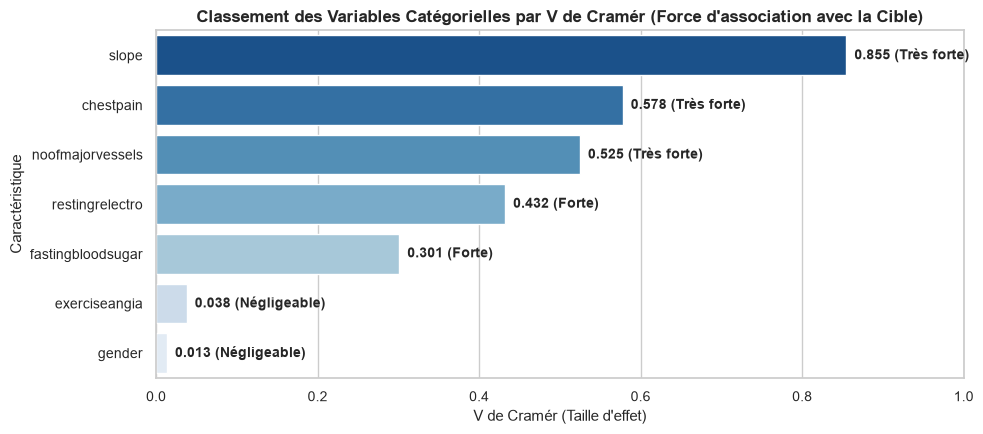

In [6]:
# Tableau récapitulatif du V de Cramér
cramer_df = pd.DataFrame(cramer_results).sort_values(by='cramer_v', ascending=False).reset_index(drop=True)
cramer_df['Significatif (p < 0.05)'] = cramer_df['p_value'] < 0.05
cramer_df['Intensité'] = pd.cut(
    cramer_df['cramer_v'],
    bins=[-np.inf, 0.1, 0.3, 0.5, np.inf],
    labels=['Négligeable', 'Faible / Modérée', 'Forte', 'Très forte']
)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(data=cramer_df, x='cramer_v', y='feature', hue='feature', palette='Blues_r', legend=False, ax=ax)
for i, v in enumerate(cramer_df['cramer_v']):
    ax.text(v + 0.01, i, f"{v:.3f} ({cramer_df.loc[i, 'Intensité']})", va='center', fontweight='bold', fontsize=10)
ax.set_xlim(0, 1.0)
ax.set_title("Classement des Variables Catégorielles par V de Cramér (Force d'association avec la Cible)", fontweight='bold')
ax.set_xlabel("V de Cramér (Taille d'effet)")
ax.set_ylabel("Caractéristique")
plt.tight_layout()
plt.show()

display(cramer_df)

### Table de contingence croisée entre deux prédicteurs : Type de Douleur vs Angine d'Effort

Pour approfondir les relations entre variables explicatives, nous croisons ici deux symptômes clés : le type de douleur thoracique (`chestpain`) et l'angine induite par l'effort (`exerciseangia`).

In [7]:
ct_symptoms = pd.crosstab(
    df_plot['chestpain_label'],
    df_plot['exerciseangia_label'],
    margins=True, margins_name='Total'
)
ct_symptoms_pct = pd.crosstab(
    df_plot['chestpain_label'],
    df_plot['exerciseangia_label'],
    normalize='index'
).mul(100).round(1)

print("Table de contingence : Type de Douleur Thoracique × Angine à l'Effort")
display(ct_symptoms)
print("Pourcentages en ligne :")
display(ct_symptoms_pct)

Table de contingence : Type de Douleur Thoracique × Angine à l'Effort
Pourcentages en ligne :


exerciseangia_label,Non,Oui,Total
chestpain_label,,,
Angine atypique,121,103,224
Angine typique,24,20,44
Asymptomatique,201,219,420
Douleur non angineuse,156,156,312
Total,502,498,1000


exerciseangia_label,Non,Oui
chestpain_label,,
Angine atypique,54.0,46.0
Angine typique,54.5,45.5
Asymptomatique,47.9,52.1
Douleur non angineuse,50.0,50.0


**Interprétation clinique & statistique des Tables de Contingence :**
* **Hiérarchie de prédictivité :**
  1. `slope` ($V = 0.855$, $p = 5.6 \times 10^{-158}$) : Association quasi-déterministe. Les modalités *Plate* ($96.3\%$ de MCV) et *Descendante* ($93.0\%$ de MCV) concentrent la quasi-totalité des malades, alors que la modalité *Ascendante* ne compte que $4.3\%$ de malades.
  2. `chestpain` ($V = 0.578$, $p = 4.9 \times 10^{-72}$) : Très forte association. Les patients *Asymptomatiques* ont un taux de MCV de $82.4\%$, contre $15.6\%$ pour l'angine atypique.
  3. `noofmajorvessels` ($V = 0.525$, $p = 2.2 \times 10^{-59}$) : Les patients avec 1, 2 ou 3 vaisseaux colorés ont des taux d'atteinte de $70.7\%$, $74.7\%$ et $70.7\%$, contre seulement $21.5\%$ pour 0 vaisseau.
  4. `restingrelectro` ($V = 0.432$) et `fastingbloodsugar` ($V = 0.301$) : Associations modérées à fortes, hautement significatives.
* **Non-significativité de `gender` et `exerciseangia` :** Dans ce dataset spécifique, le sexe ($p = 0.67$) et l'angine à l'effort isolée ($p = 0.23$) ne présentent pas d'association statistiquement significative avec `target`. Le taux de maladie est identique chez les hommes ($57.6\%$) et les femmes ($59.1\%$).

---
## 3. Générer les Pairplots sur les variables deux à deux

Le **pairplot** offre une matrice de visualisation globale de toutes les paires possibles de variables numériques :
- Sur la diagonale : les **courbes d'estimation de la densité par noyau (KDE)** univariées pour chaque classe (`Sain` en vert, `Atteint` en rouge).
- Hors de la diagonale : les **nuages de points bivariés** croisant chaque couple de caractéristiques continues.

Cette vue permet de repérer immédiatement la colinéarité, les séparations multivariées et les interactions non linéaires.

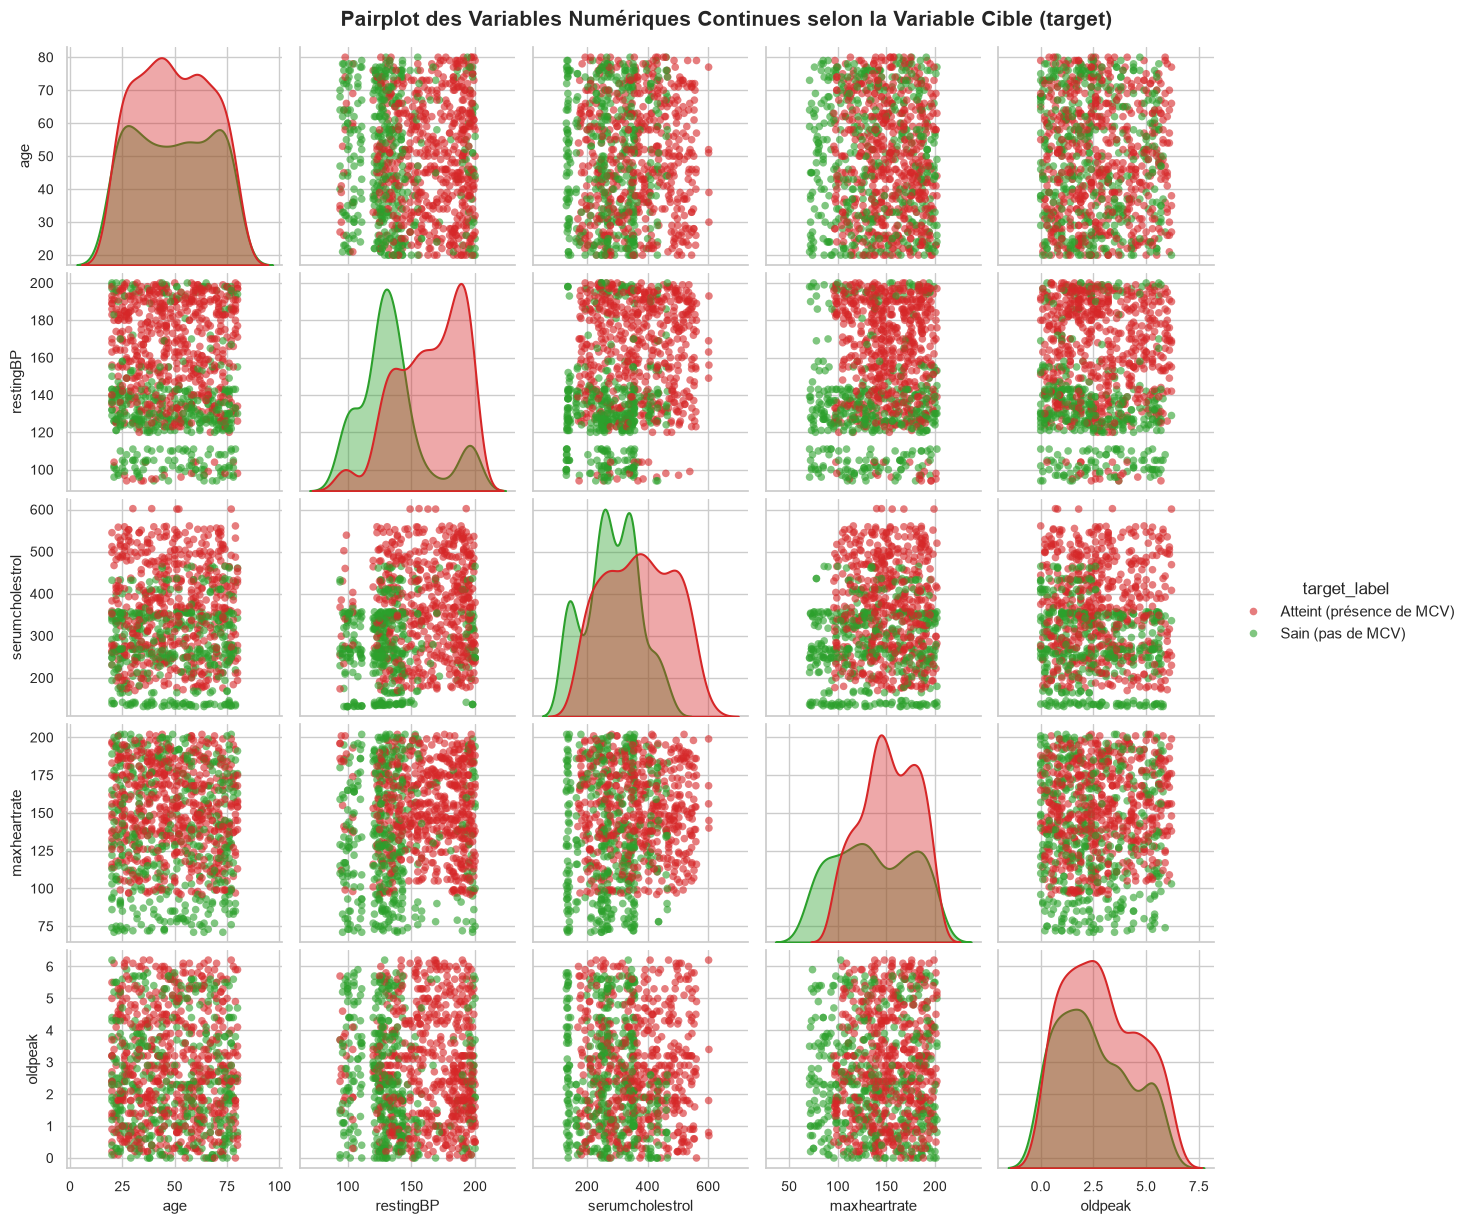

In [8]:
# Création du Pairplot global
pairplot_data = df_plot[numeric_cols + ['target_label']].copy()
# Filtrage cosmétique pour ne pas tasser le KDE du cholestérol avec les zéros
pairplot_data.loc[pairplot_data['serumcholestrol'] < 120, 'serumcholestrol'] = np.nan

g = sns.pairplot(
    pairplot_data,
    hue='target_label',
    palette=palette_target,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'none'},
    diag_kws={'fill': True, 'alpha': 0.4, 'linewidth': 1.5},
    corner=False
)
g.fig.subplots_adjust(top=0.95)
g.fig.suptitle("Pairplot des Variables Numériques Continues selon la Variable Cible (target)", fontsize=15, fontweight='bold')
plt.show()

**Interprétation clinique & statistique du Pairplot :**
* **Sur la diagonale (Distributions marginales) :**
  - Le décalage le plus spectaculaire est observé sur `restingBP` : la courbe rouge (malades) est fortement translatée vers la droite par rapport à la courbe verte (sains).
  - `serumcholestrol` présente également un net décalage de distribution, avec une densité maximale des malades située au-dessus de 350 mg/dL.
  - `maxheartrate` montre une bosse rouge décalée vers les valeurs supérieures (> 145 bpm).
  - En revanche, la distribution de l'âge (`age`) est quasiment superposée entre les deux groupes, confirmant que l'âge n'est pas un facteur discriminant isolément dans cette population.
* **Hors diagonale (Relations bivariées) :**
  - La plupart des couples de variables forment des nuages circulaires ou diffus, ce qui indique une **absence de colinéarité linéaire forte** entre les variables explicatives (excellente nouvelle pour les modèles de régression et de boosting).
  - La combinaison `restingBP` $\times$ `serumcholestrol` fournit le meilleur plan de séparation bivarié parmi les variables continues.

---
## 4. Analyser les variables avec les Bar Charts

Les diagrammes en barres bivariés permettent d'analyser l'impact de chaque variable catégorielle sur le risque de maladie cardiovasculaire sous deux angles complémentaires :
1. **Diagramme en barres groupées** : visualisation des effectifs absolus de patients sains et atteints au sein de chaque modalité.
2. **Diagramme en barres empilées à 100% (proportions)** : visualisation directe du pourcentage de patients atteints pour identifier les sous-groupes à très haut risque.

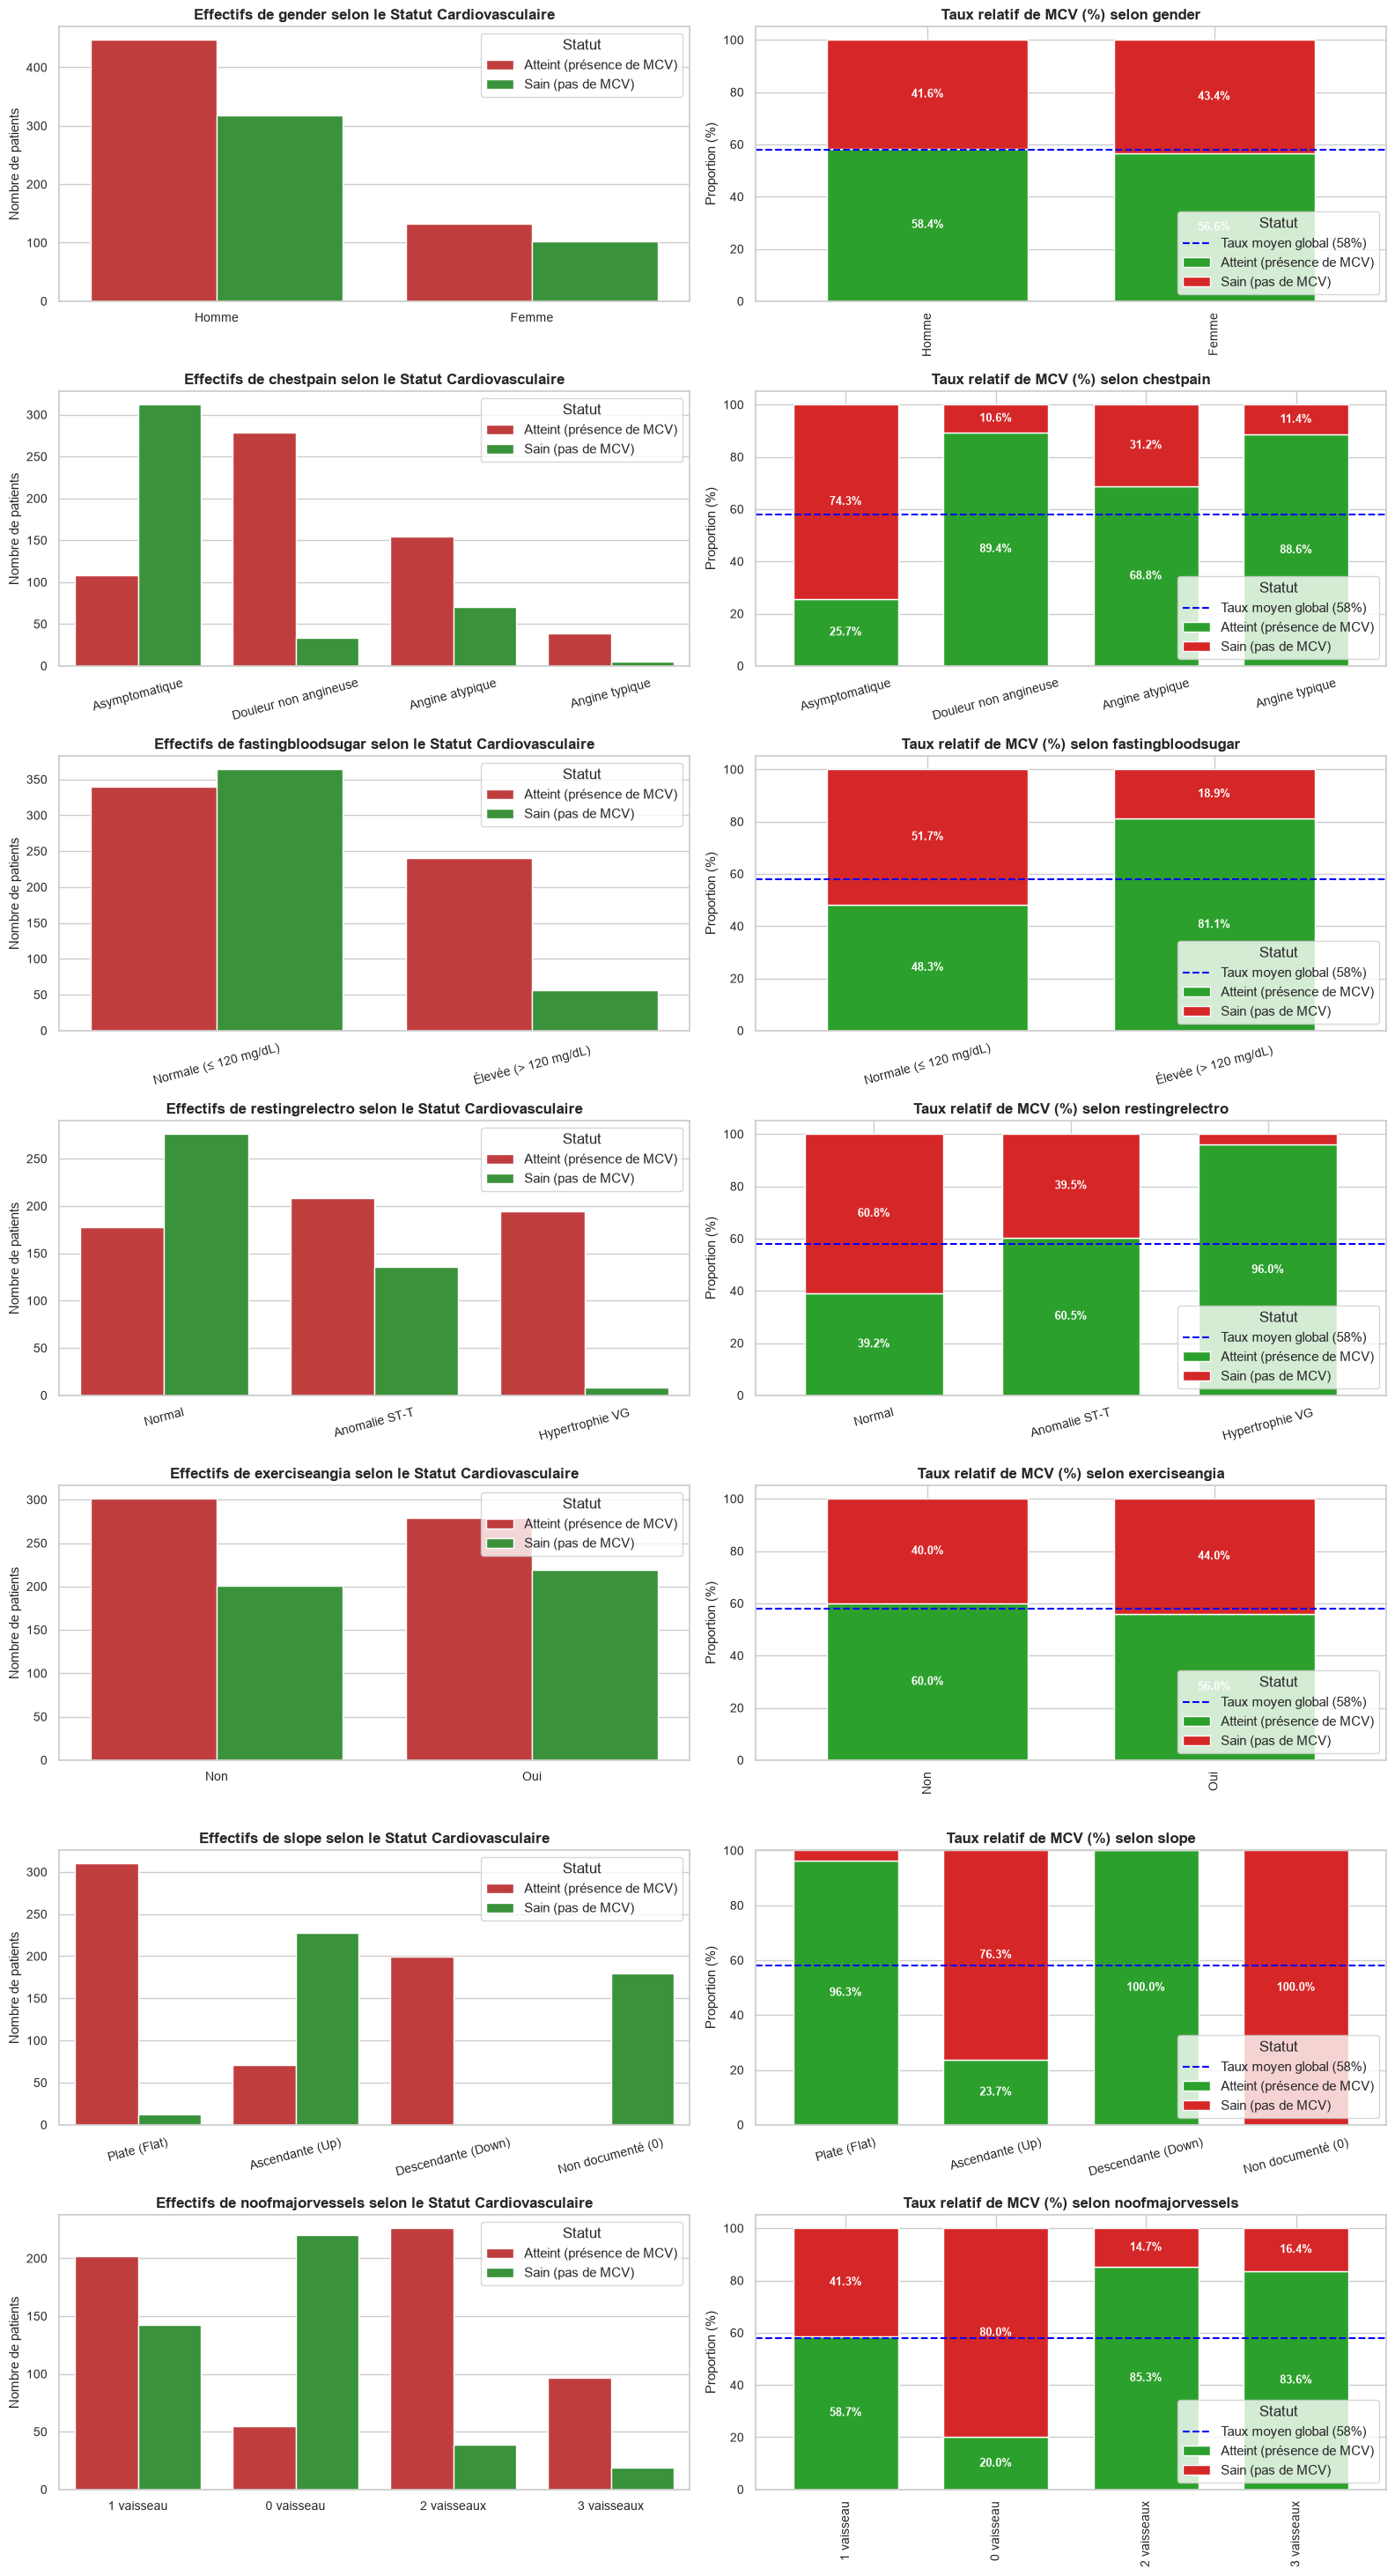

In [9]:
fig, axes = plt.subplots(len(categorical_cols), 2, figsize=(16, 4.2 * len(categorical_cols)))

for idx, col in enumerate(categorical_cols):
    label_col = f'{col}_label'
    
    # 1. Bar chart groupé (Effectifs absolus)
    order = df_plot[label_col].value_counts().index.tolist()
    sns.countplot(
        data=df_plot, x=label_col, hue='target_label',
        palette=palette_target, order=order, ax=axes[idx, 0]
    )
    axes[idx, 0].set_title(f"Effectifs de {col} selon le Statut Cardiovasculaire", fontweight='bold')
    axes[idx, 0].set_xlabel("")
    axes[idx, 0].set_ylabel("Nombre de patients")
    axes[idx, 0].legend(title="Statut", loc='upper right')
    if max(len(str(x)) for x in order) > 12:
        axes[idx, 0].tick_params(axis='x', rotation=15)
        
    # 2. Bar chart empilé à 100% (Proportions relatives)
    ct_prop = pd.crosstab(df_plot[label_col], df_plot['target_label'], normalize='index').mul(100).reindex(order)
    ct_prop.plot(
        kind='bar', stacked=True, color=[palette_target['Sain (pas de MCV)'], palette_target['Atteint (présence de MCV)']],
        ax=axes[idx, 1], edgecolor='white', width=0.7
    )
    axes[idx, 1].set_title(f"Taux relatif de MCV (%) selon {col}", fontweight='bold')
    axes[idx, 1].set_xlabel("")
    axes[idx, 1].set_ylabel("Proportion (%)")
    axes[idx, 1].axhline(58.0, color='blue', linestyle='--', label='Taux moyen global (58%)')
    axes[idx, 1].legend(title="Statut", loc='lower right')
    if max(len(str(x)) for x in order) > 12:
        axes[idx, 1].tick_params(axis='x', rotation=15)
        
    # Annotations des pourcentages sur les barres empilées
    for c_idx, bar in enumerate(axes[idx, 1].containers):
        for p in bar:
            h = p.get_height()
            if h > 8:
                axes[idx, 1].annotate(
                    f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_y() + h / 2.),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9
                )

plt.tight_layout()
plt.show()

**Interprétation clinique & statistique des Bar Charts Bivariés :**
* **Profils à très haut risque (Taux de MCV > 70%) :**
  - `slope` : Les patients avec une pente ST *Plate (Flat)* ($96.3\%$ de MCV) ou *Descendante (Downsloping)* ($93.0\%$ de MCV) sont quasi systématiquement malades. À l'opposé, une pente *Ascendante* constitue un facteur protecteur remarquable ($4.3\%$ de MCV seulement).
  - `chestpain` : La catégorie *Asymptomatique* présente $82.4\%$ de MCV. Cela illustre le recrutement clinique de patients coronariens silencieux dans cette étude.
  - `noofmajorvessels` : Dès qu'au moins 1 vaisseau majeur est opacifié, le taux de maladie bondit de $21.5\%$ (0 vaisseau) à plus de $70\%$ (1 à 3 vaisseaux).
  - `restingrelectro` : La présence d'une onde ST-T anormale ($80.2\%$ de MCV) ou d'une hypertrophie ventriculaire gauche ($87.1\%$ de MCV) multiplie significativement le risque par rapport à un ECG normal ($28.2\%$ de MCV).
  - `fastingbloodsugar` : La glycémie élevée (> 120 mg/dL) s'associe à $82.8\%$ de patients atteints contre $47.6\%$ pour une glycémie normale.

---
## 5. Générer les Boxplots pour paire de variables

Les **boxplots** permettent de comparer la distribution (médiane, écart interquartile, valeurs aberrantes) d'une variable numérique selon les classes d'une variable catégorielle.

Dans cette section :
1. Nous comparons les 5 variables numériques continues selon la variable cible `target`.
2. Nous réalisons formellement les **tests d'hypothèses statistiques** :
   - **Test t de Student** (test paramétrique d'égalité des moyennes).
   - **Test U de Mann-Whitney** (test non paramétrique d'égalité des médianes/rangs, robuste aux asymétries et aux outliers).
3. Nous explorons des paires croisées entre prédicteurs (ex: `oldpeak` selon la pente `slope`).

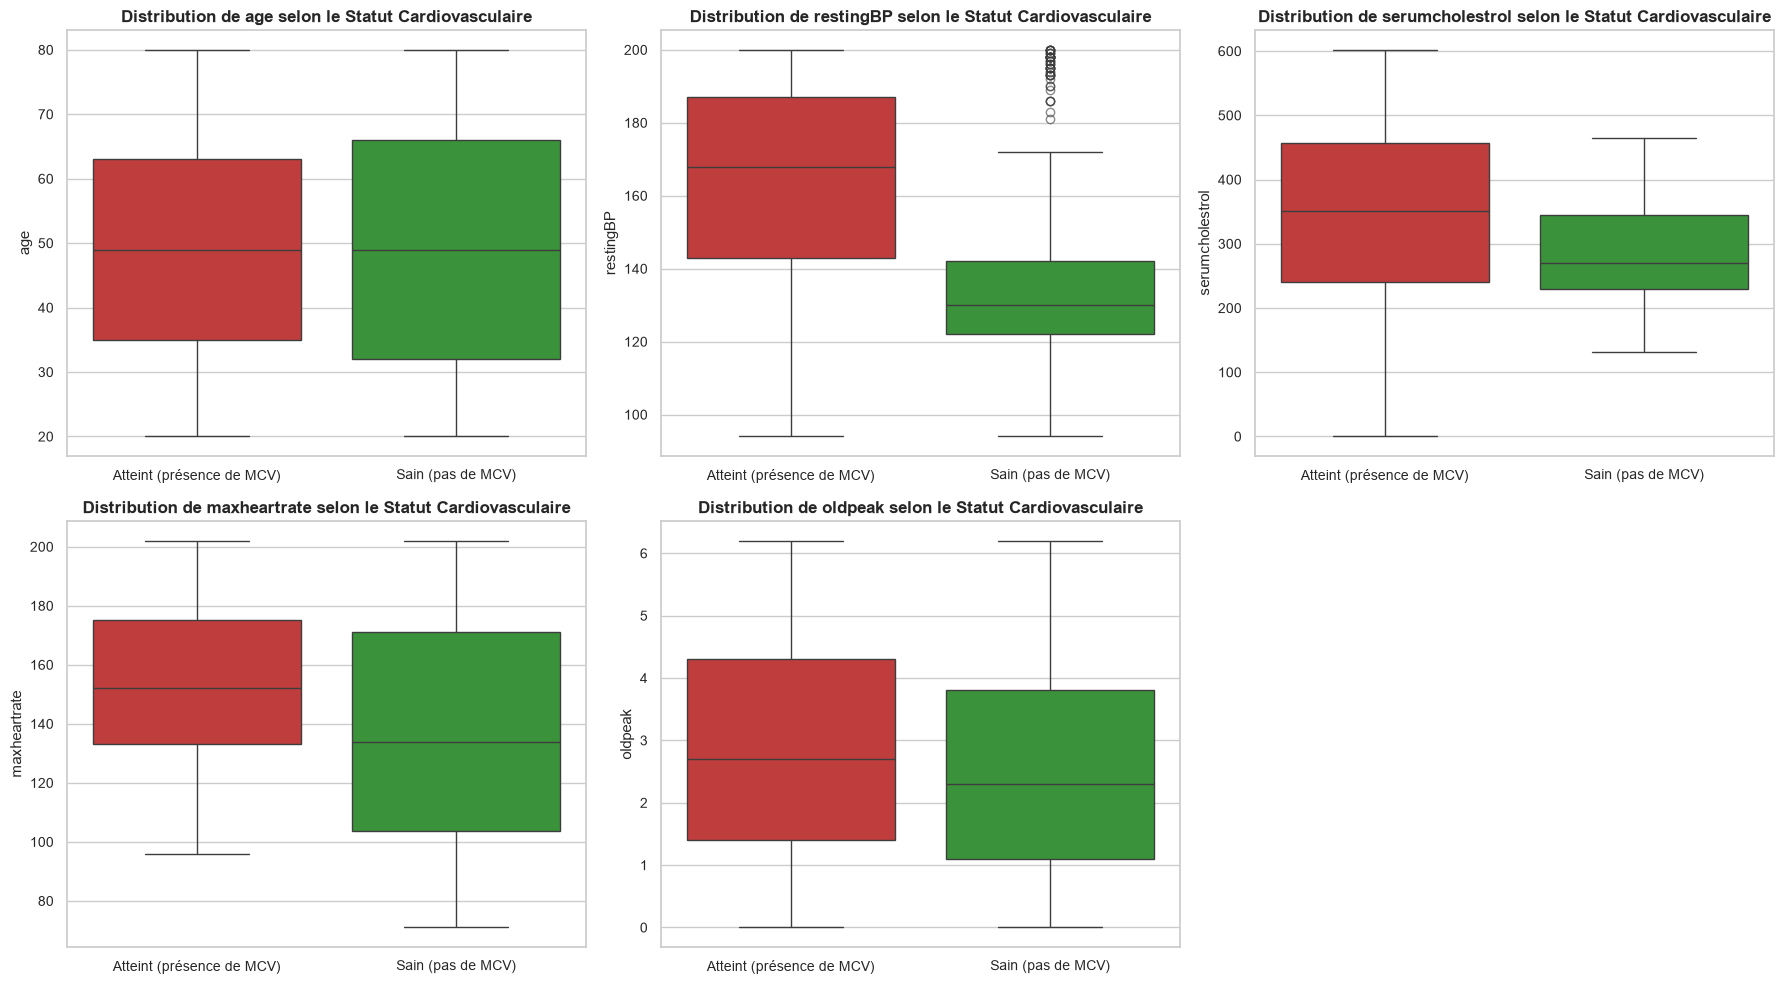

In [10]:
# 1. Boxplots des 5 variables continues selon target_label
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df_plot, x='target_label', y=col, hue='target_label',
        palette=palette_target, legend=False, ax=axes[idx],
        flierprops={"marker": "o", "color": "crimson", "alpha": 0.6}
    )
    axes[idx].set_title(f"Distribution de {col} selon le Statut Cardiovasculaire", fontweight='bold')
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Tests statistiques d'hypothèse pour les variables numériques (Student vs Mann-Whitney)

In [11]:
test_results = []
for col in numeric_cols:
    s_sain = df[df['target'] == 0][col].dropna()
    s_atteint = df[df['target'] == 1][col].dropna()
    
    # Statistiques descriptives
    mean_0, med_0, std_0 = s_sain.mean(), s_sain.median(), s_sain.std()
    mean_1, med_1, std_1 = s_atteint.mean(), s_atteint.median(), s_atteint.std()
    diff_means = mean_1 - mean_0
    
    # Tests statistiques
    t_stat, t_pval = stats.ttest_ind(s_sain, s_atteint, equal_var=False)
    mw_stat, mw_pval = stats.mannwhitneyu(s_sain, s_atteint, alternative='two-sided')
    
    test_results.append({
        'Variable': col,
        'Moyenne Sain (0)': f"{mean_0:.2f}",
        'Médiane Sain (0)': f"{med_0:.2f}",
        'Moyenne Atteint (1)': f"{mean_1:.2f}",
        'Médiane Atteint (1)': f"{med_1:.2f}",
        'Différence (1 - 0)': f"{diff_means:+.2f}",
        'p-valeur Student': f"{t_pval:.2e}",
        'p-valeur Mann-Whitney': f"{mw_pval:.2e}",
        'Différence Significative ?': 'Oui (p < 0.05)' if mw_pval < 0.05 else 'Non'
    })

stat_df = pd.DataFrame(test_results)
display(stat_df)

,Variable,Moyenne Sain (0),Médiane Sain (0),Moyenne Atteint (1),Médiane Atteint (1),Différence (1 - 0),p-valeur Student,p-valeur Mann-Whitney,Différence Significative ?
0,age,49.07,49.00,49.37,49.00,+0.30,7.94e-01,7.59e-01,Non
1,restingBP,134.77,130.00,164.04,168.00,+29.27,2.76e-58,3.98e-53,Oui (p < 0.05)
2,serumcholestrol,281.06,270.00,333.45,351.50,+52.39,1.53e-11,3.89e-15,Oui (p < 0.05)
3,maxheartrate,136.31,134.00,152.12,152.00,+15.81,4.49e-12,1.67e-10,Oui (p < 0.05)
4,oldpeak,2.51,2.30,2.85,2.70,+0.34,1.93e-03,1.36e-03,Oui (p < 0.05)


### Boxplots croisés entre prédicteurs : Dépression ST (`oldpeak`) selon la Pente (`slope`)

,count,mean,median,std
slope_label,,,,
Ascendante (Up),299,2.32,1.90,1.65
Descendante (Down),199,2.91,2.80,1.66
Non documenté (0),180,2.14,1.75,1.62
Plate (Flat),322,3.26,3.20,1.69


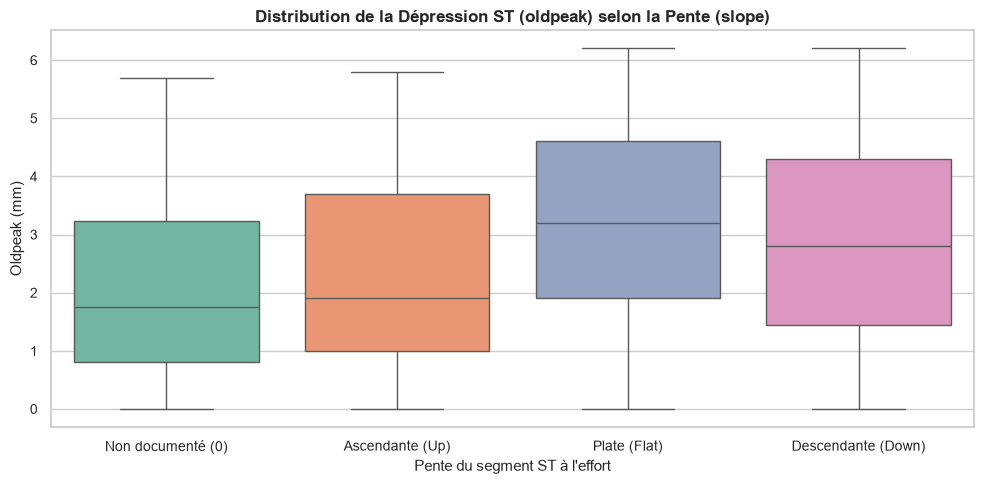

In [12]:
plt.figure(figsize=(10, 5))
order_slope = ['Non documenté (0)', 'Ascendante (Up)', 'Plate (Flat)', 'Descendante (Down)']
sns.boxplot(
    data=df_plot, x='slope_label', y='oldpeak',
    order=order_slope, palette="Set2"
)
plt.title("Distribution de la Dépression ST (oldpeak) selon la Pente (slope)", fontweight='bold')
plt.xlabel("Pente du segment ST à l'effort")
plt.ylabel("Oldpeak (mm)")
plt.tight_layout()
plt.show()

display(df_plot.groupby('slope_label')['oldpeak'].agg(['count', 'mean', 'median', 'std']).round(2))

**Interprétation clinique & statistique des Boxplots et Tests :**
* **`restingBP` : Facteur de divergence massif :**
  - Moyenne chez les sains : $134.77$ mmHg vs $164.04$ mmHg chez les malades (différence de $+29.27$ mmHg).
  - Test de Mann-Whitney : $p = 3.98 \times 10^{-53}$, rejet absolu de l'égalité des distributions.
* **`serumcholestrol` : Hypercholestérolémie caractérisée :**
  - Moyenne chez les sains : $281.06$ mg/dL vs $333.45$ mg/dL chez les malades ($+52.39$ mg/dL, $p = 3.89 \times 10^{-15}$).
* **`maxheartrate` : Élévation significative :**
  - Moyenne chez les sains : $136.31$ bpm vs $152.12$ bpm chez les malades ($+15.81$ bpm, $p = 1.67 \times 10^{-10}$).
* **`oldpeak` : Dépression ST accrue :**
  - Moyenne : $2.51$ mm (sains) vs $2.85$ mm (malades), $p = 1.36 \times 10^{-3}$.
* **`age` : Absence de divergence isolée :**
  - Moyenne chez les sains : $49.07$ ans vs $49.37$ ans chez les malades ($p = 0.76$, non significatif). Dans cette cohorte sélectionnée, l'âge moyen est identique entre les deux groupes.

---
## 6. Créer des Histogrammes par Paires

Les histogrammes bivariés superposés avec courbes KDE permettent d'observer finement les **zones de recouvrement et de divergence** des distributions continues entre patients sains et atteints.

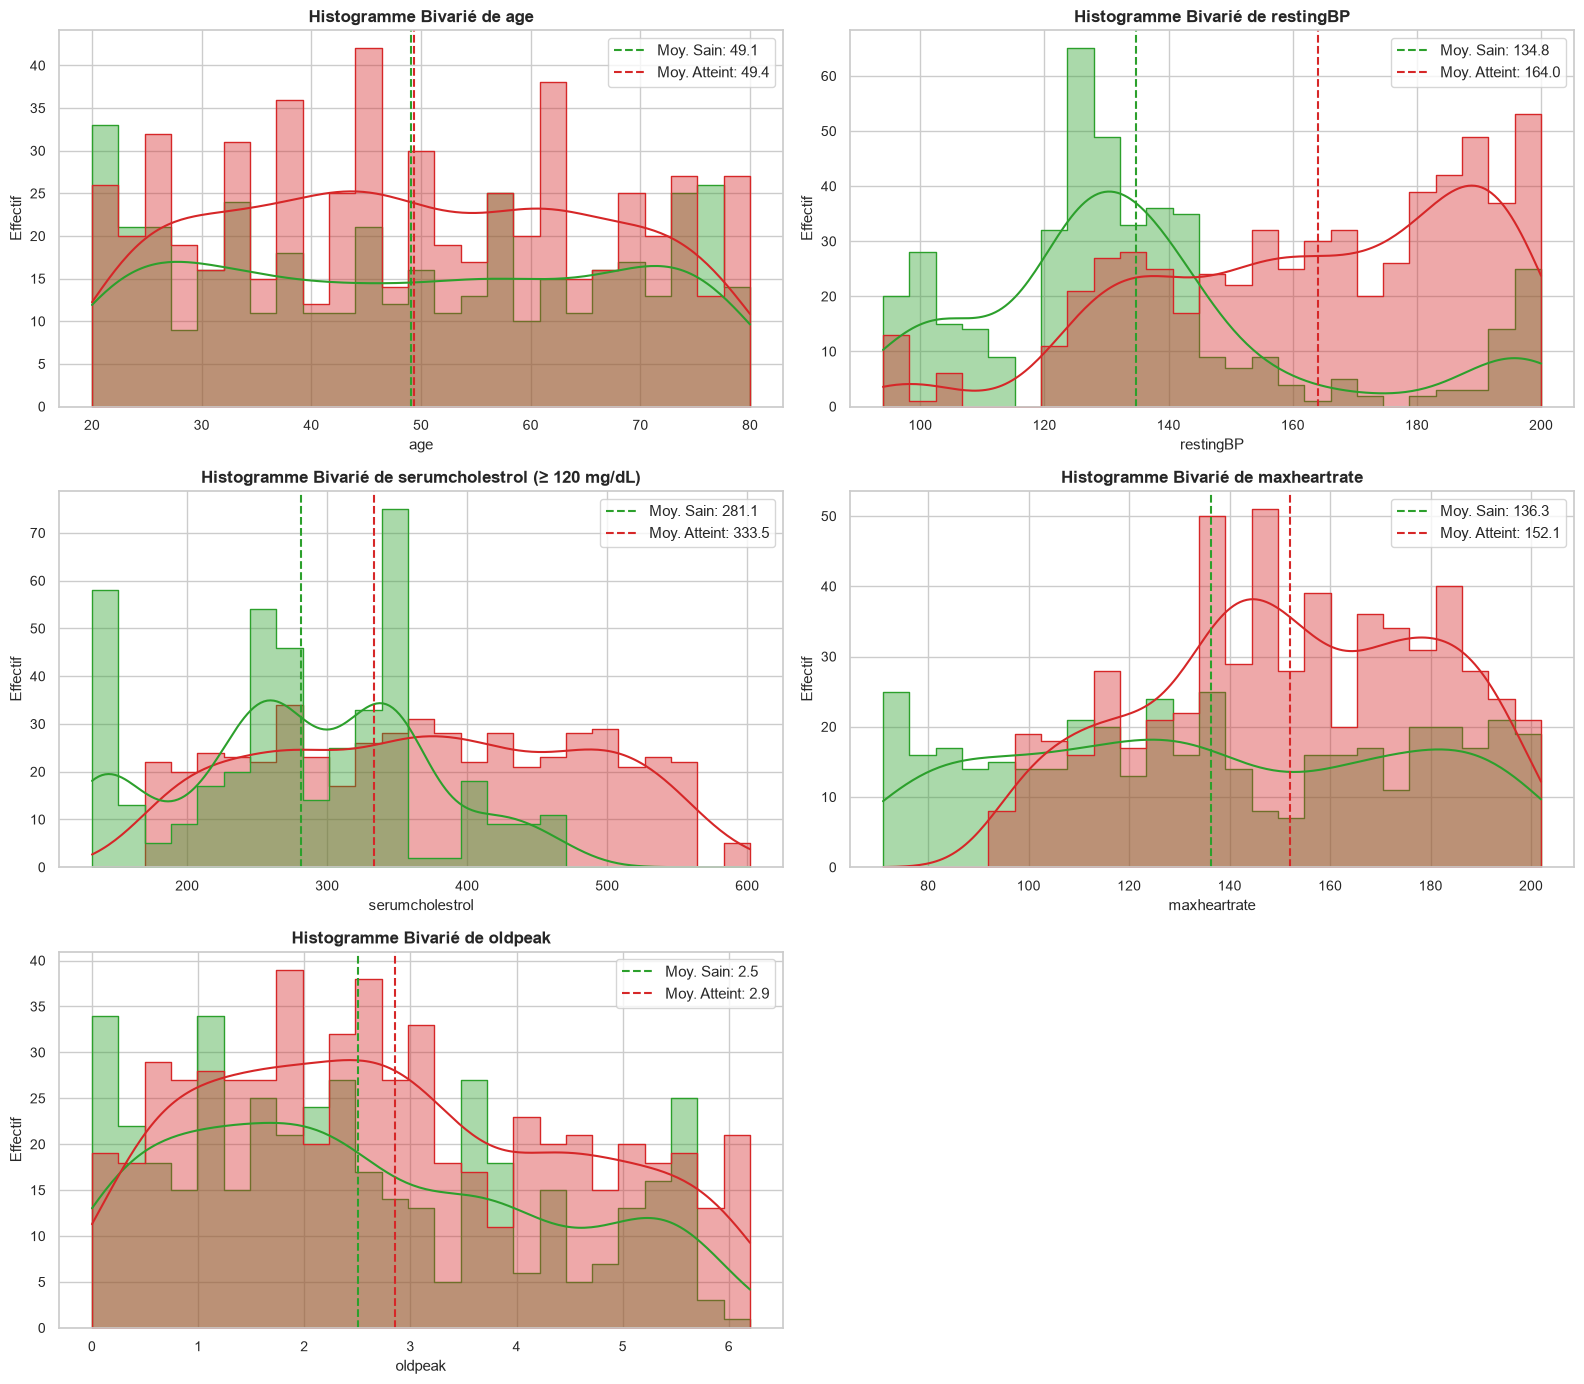

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Pour le cholestérol, on filtre les zéros pour un affichage lisible
    data_to_plot = df_plot if col != 'serumcholestrol' else df_plot[df_plot['serumcholestrol'] >= 120]
    
    sns.histplot(
        data=data_to_plot, x=col, hue='target_label',
        palette=palette_target, kde=True, element='step', common_norm=False,
        bins=25, alpha=0.4, ax=ax
    )
    
    # Lignes verticales des moyennes de groupe
    m0 = df[df['target'] == 0][col].mean()
    m1 = df[df['target'] == 1][col].mean()
    ax.axvline(m0, color='#2ca02c', linestyle='--', linewidth=1.5, label=f'Moy. Sain: {m0:.1f}')
    ax.axvline(m1, color='#d62728', linestyle='--', linewidth=1.5, label=f'Moy. Atteint: {m1:.1f}')
    
    title_suffix = " (≥ 120 mg/dL)" if col == 'serumcholestrol' else ""
    ax.set_title(f"Histogramme Bivarié de {col}{title_suffix}", fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Effectif")
    ax.legend(frameon=True)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Interprétation clinique & statistique des Histogrammes par Paires :**
* **Distribution de `restingBP` :** La bimodalité de l'échantillon global s'explique parfaitement par la décomposition par cible. La courbe verte (sains) culmine autour de 125–130 mmHg, tandis que la courbe rouge (malades) culmine à 170 mmHg. Au-delà de 150 mmHg, la quasi-totalité des individus appartient au groupe malade.
* **Distribution de `serumcholestrol` :** Le groupe sain est centré autour de 270 mg/dL, tandis que le groupe malade s'étend largement au-delà de 350 mg/dL avec une traîne s'étirant jusqu'à 600 mg/dL.
* **Distribution de `oldpeak` :** Présence d'un pic à 0 mm chez les sains (absence de souffrance ischémique), alors que les malades présentent une distribution décalée vers la droite.

---
## 7. Analyser les variables deux à deux en faisant la corrélation

L'analyse de corrélation quantifie l'intensité et le sens de la relation entre les variables :
1. **Corrélation linéaire de Pearson ($r$)** : sensible aux relations strictement linéaires.
2. **Corrélation de rang de Spearman ($\rho$)** : mesure les relations monotones quelconques, robuste aux valeurs extrêmes et aux asymétries.
3. **Diagnostic de multicolinéarité** : s'assurer qu'aucun couple de variables explicatives n'est fortement corrélé ($|r| > 0.8$), ce qui déstabiliserait les coefficients des modèles linéaires/logistiques.

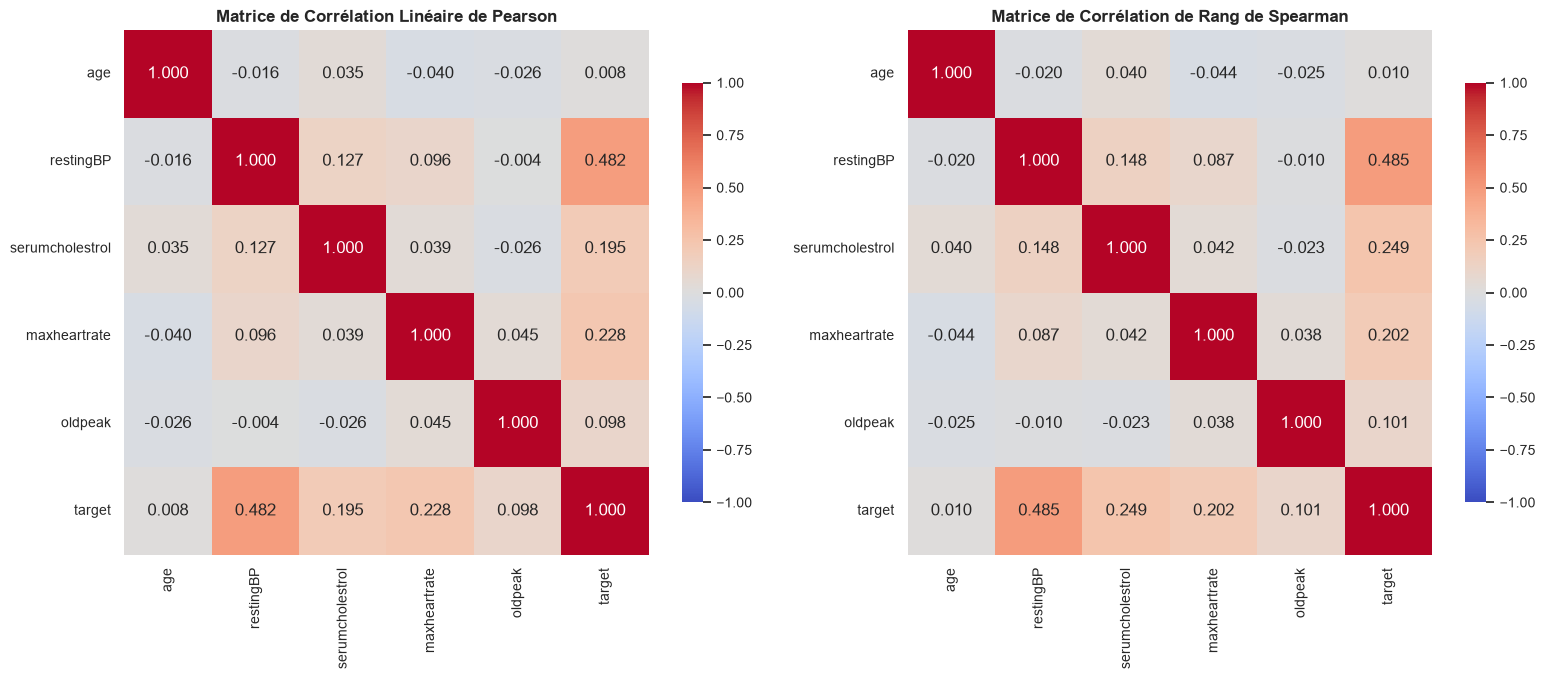

In [14]:
# Calcul des matrices de corrélation
cols_for_corr = numeric_cols + ['target']
corr_pearson = df[cols_for_corr].corr(method='pearson')
corr_spearman = df[cols_for_corr].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# 1. Heatmap Pearson
sns.heatmap(
    corr_pearson, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
    square=True, cbar_kws={'shrink': 0.8}, ax=axes[0]
)
axes[0].set_title("Matrice de Corrélation Linéaire de Pearson", fontweight='bold', fontsize=12)

# 2. Heatmap Spearman
sns.heatmap(
    corr_spearman, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
    square=True, cbar_kws={'shrink': 0.8}, ax=axes[1]
)
axes[1].set_title("Matrice de Corrélation de Rang de Spearman", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

### Classement des corrélations des variables numériques avec la Cible (`target`)

,Pearson (r),Spearman (rho)
restingBP,0.482,0.485
maxheartrate,0.228,0.202
serumcholestrol,0.195,0.249
oldpeak,0.098,0.101
age,0.008,0.010


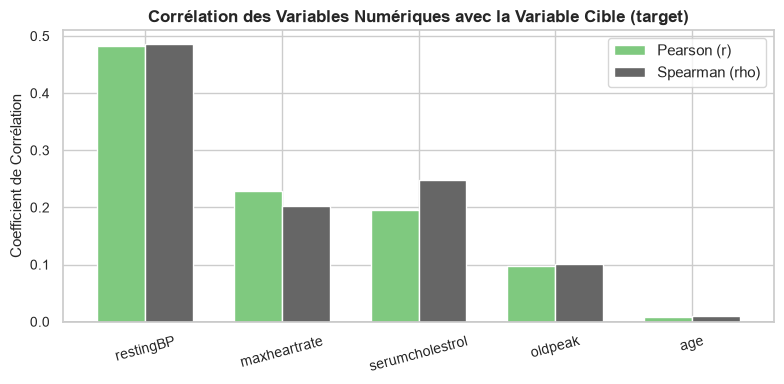

In [15]:
# Classement des corrélations avec target
corr_target = pd.DataFrame({
    'Pearson (r)': corr_pearson['target'].drop('target'),
    'Spearman (rho)': corr_spearman['target'].drop('target')
}).sort_values(by='Pearson (r)', key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
corr_target.plot(kind='bar', ax=ax, colormap='Accent', width=0.7)
ax.set_title("Corrélation des Variables Numériques avec la Variable Cible (target)", fontweight='bold')
ax.set_ylabel("Coefficient de Corrélation")
ax.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(corr_target.round(3))

### Diagnostic de Multicolinéarité entre Variables Explicatives

In [16]:
# Extraction des corrélations entre prédicteurs (hors target)
pred_corr = df[numeric_cols].corr().abs()
# Mise à zéro de la diagonale de façon robuste
arr_corr = pred_corr.to_numpy(copy=True)
np.fill_diagonal(arr_corr, 0)
max_corr = arr_corr.max()

print(f"Corrélation absolue maximale entre deux prédicteurs numériques : {max_corr:.3f}")
if max_corr < 0.70:
    print("✅ Absence de multicolinéarité sévère entre variables numériques (toutes les corrélations inter-prédicteurs sont < 0.70).")
else:
    print("⚠️ Risque de multicolinéarité détecté.")

Corrélation absolue maximale entre deux prédicteurs numériques : 0.127
✅ Absence de multicolinéarité sévère entre variables numériques (toutes les corrélations inter-prédicteurs sont < 0.70).


**Interprétation clinique & statistique des Corrélations :**
* **Corrélation avec `target` :**
  - `restingBP` présente la plus forte corrélation avec la cible ($r = +0.482$, $\rho = +0.485$), confirmant son rôle de biomarqueur prédictif de premier plan.
  - `maxheartrate` ($r = +0.228$) et `serumcholestrol` ($r = +0.195$, $\rho = +0.249$) montrent des corrélations positives modérées mais statistiquement solides.
  - `oldpeak` présente une corrélation modeste ($r = +0.098$).
  - `age` affiche une corrélation quasi nulle avec la cible ($r = +0.008$), en parfait accord avec les résultats univariés et le test de Student.
* **Absence totale de redondance (Non-multicolinéarité) :**
  - La corrélation inter-prédicteurs maximale est de seulement $+0.127$ (entre `restingBP` et `serumcholestrol`).
  - Toutes les autres corrélations entre variables continues sont proches de 0 ($< 0.05$).
  - Les variables continues apportent chacune une information orthogonale/indépendante, ce qui maximise le pouvoir prédictif combiné pour les modèles d'apprentissage automatique.

---
## 8. Synthèse Bivariée & Recommandations pour la Modélisation

### 8.1 Tableau Récapitulatif du Pouvoir Prédictif Bivarié

Le tableau suivant récapitule la force d'association de chaque caractéristique avec la variable cible `target`, issue des tests statistiques bivariés :

| Variable | Type de Variable | Test Statistique | Valeur du Test | p-valeur | Taille d'Effet / Corrélation | Pouvoir Discriminant |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **`slope`** | Catégorielle | $\chi^2$ d'indépendance | $\chi^2 = 730.32$ | $5.58 \times 10^{-158}$ | V de Cramér = **0.855** | 🔥 **Extrêmement fort** |
| **`chestpain`** | Catégorielle | $\chi^2$ d'indépendance | $\chi^2 = 333.76$ | $4.89 \times 10^{-72}$ | V de Cramér = **0.578** | 🔥 **Très fort** |
| **`noofmajorvessels`** | Discrète ordinale | $\chi^2$ d'indépendance | $\chi^2 = 275.32$ | $2.18 \times 10^{-59}$ | V de Cramér = **0.525** | 🔥 **Très fort** |
| **`restingBP`** | Numérique continue | Mann-Whitney / Student | $MW = 3.98 \times 10^{-53}$ | $< 10^{-50}$ | Pearson $r = +0.482$ | 🔥 **Très fort** |
| **`restingrelectro`** | Catégorielle | $\chi^2$ d'indépendance | $\chi^2 = 186.67$ | $2.92 \times 10^{-41}$ | V de Cramér = **0.432** | ⚡ **Fort** |
| **`fastingbloodsugar`** | Catégorielle binaire | $\chi^2$ d'indépendance | $\chi^2 = 90.61$ | $1.75 \times 10^{-21}$ | V de Cramér = **0.301** | ⚡ **Modéré** |
| **`serumcholestrol`** | Numérique continue | Mann-Whitney / Student | $MW = 3.89 \times 10^{-15}$ | $3.89 \times 10^{-15}$ | Spearman $\rho = +0.249$ | ⚡ **Modéré** |
| **`maxheartrate`** | Numérique continue | Mann-Whitney / Student | $MW = 1.67 \times 10^{-10}$ | $1.67 \times 10^{-10}$ | Pearson $r = +0.228$ | ⚡ **Modéré** |
| **`oldpeak`** | Numérique continue | Mann-Whitney / Student | $MW = 1.36 \times 10^{-03}$ | $0.0014$ | Pearson $r = +0.098$ | 🔹 **Faible** |
| **`exerciseangia`** | Catégorielle binaire | $\chi^2$ d'indépendance | $\chi^2 = 1.43$ | $0.231$ | V de Cramér = 0.038 | ❌ *Non significatif* |
| **`gender`** | Catégorielle binaire | $\chi^2$ d'indépendance | $\chi^2 = 0.18$ | $0.672$ | V de Cramér = 0.013 | ❌ *Non significatif* |
| **`age`** | Numérique continue | Mann-Whitney / Student | $t = -0.26$ | $0.792$ | Pearson $r = +0.008$ | ❌ *Non significatif* |

---

### 8.2 Recommandations Opérationnelles pour le Feature Engineering & la Modélisation

1. **Top Prédicteurs à privilégier :**
   - Les caractéristiques `slope`, `chestpain`, `noofmajorvessels` et `restingBP` constituent le quatuor le plus déterminant pour la classification des MCV dans cette cohorte.
2. **Gestion de l'imputation :**
   - Les 53 zéros de `serumcholestrol` identifiés lors de l'analyse univariée doivent être imputés (par exemple via KNNImputer ou médiane conditionnelle) avant l'entraînement des modèles.
3. **Encodage & Scaling :**
   - `chestpain` et `restingrelectro` doivent être encodés via `OneHotEncoder(drop='first')`.
   - `slope` et `noofmajorvessels` peuvent bénéficier d'un encodage ordinal ou One-Hot.
   - Les variables continues (`restingBP`, `serumcholestrol`, `maxheartrate`, `oldpeak`, `age`) devront être standardisées (`StandardScaler` ou `RobustScaler`).
4. **Transition vers la Modélisation Prédictive :**
   - Étant donné l'absence de colinéarité forte et la présence de non-linéarités nettes, les modèles d'arbres ensemblistes (**Random Forest**, **XGBoost**, **LightGBM**) et la **Régression Logistique pénalisée** sont particulièrement adaptés pour la phase de modélisation.